Choose Placement Dataset CSV file:


Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv

First 5 rows:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInte

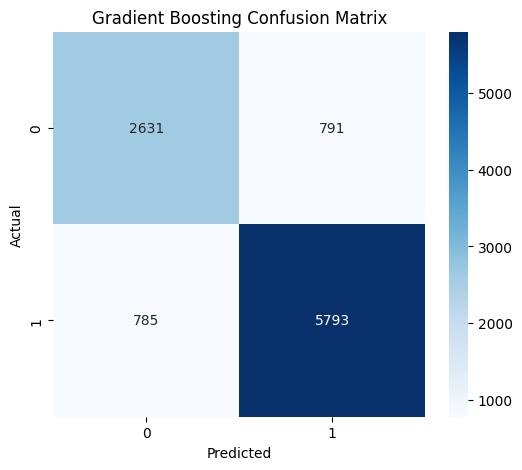


Feature Importance:
CGPA : 1.0


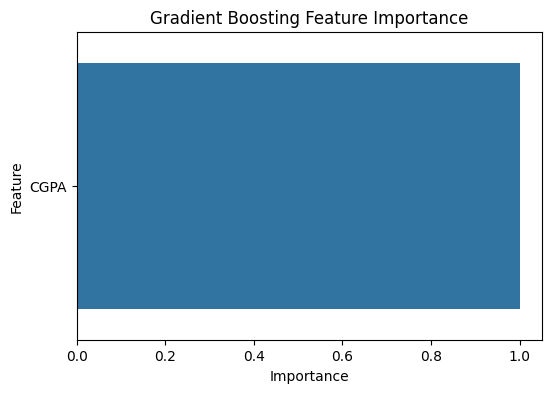

In [1]:
# ============================================================
# GRADIENT BOOSTING CLASSIFICATION
# PLACEMENT PREDICTION
# ============================================================

# 1. Import libraries
import pandas as pd

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# 2. Upload Dataset
# ============================================================

print("Choose Placement Dataset CSV file:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(filename)


# ============================================================
# 3. Display Dataset
# ============================================================

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# 4. Features
# ============================================================

X = df[["CGPA"]]


# ============================================================
# 5. Target
# ============================================================

y = df["PlacementStatus"]


# ============================================================
# 6. Split Data
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining Data:")
print(X_train.shape)

print("\nTesting Data:")
print(X_test.shape)


# ============================================================
# 7. Create Gradient Boosting Model
# ============================================================

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)


# ============================================================
# 8. Train Model
# ============================================================

model.fit(
    X_train,
    y_train
)

print("\nModel Training Completed!")


# ============================================================
# 9. Prediction
# ============================================================

y_pred = model.predict(
    X_test
)

print("\nPredicted Values:")
print(y_pred)


# ============================================================
# 10. Accuracy
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(accuracy)


# ============================================================
# 11. Classification Report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 12. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")

plt.show()


# ============================================================
# 13. Feature Importance
# ============================================================

importance = model.feature_importances_

print("\nFeature Importance:")

for feature, value in zip(
    X.columns,
    importance
):
    print(feature, ":", value)


# ============================================================
# 14. Feature Importance Plot
# ============================================================

plt.figure(figsize=(6, 4))

sns.barplot(
    x=importance,
    y=X.columns
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()